In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("/content/cleaned_mental_health_data.csv")
print(df)

                                               Indicator     Group  \
0                        Symptoms of Depressive Disorder    By Age   
1                        Symptoms of Depressive Disorder    By Age   
2                        Symptoms of Depressive Disorder    By Age   
3                        Symptoms of Depressive Disorder    By Age   
4                        Symptoms of Depressive Disorder    By Age   
...                                                  ...       ...   
14035  Symptoms of Anxiety Disorder or Depressive Dis...  By State   
14036  Symptoms of Anxiety Disorder or Depressive Dis...  By State   
14037  Symptoms of Anxiety Disorder or Depressive Dis...  By State   
14038  Symptoms of Anxiety Disorder or Depressive Dis...  By State   
14039  Symptoms of Anxiety Disorder or Depressive Dis...  By State   

               State       Subgroup Phase  Time Period      Time Period Label  \
0      United States  18 - 29 years     1            1   Apr 23 - May 5, 2020 

In [37]:
# Unique Categories
df['Indicator'].unique()

array(['Symptoms of Depressive Disorder', 'Symptoms of Anxiety Disorder',
       'Symptoms of Anxiety Disorder or Depressive Disorder'],
      dtype=object)

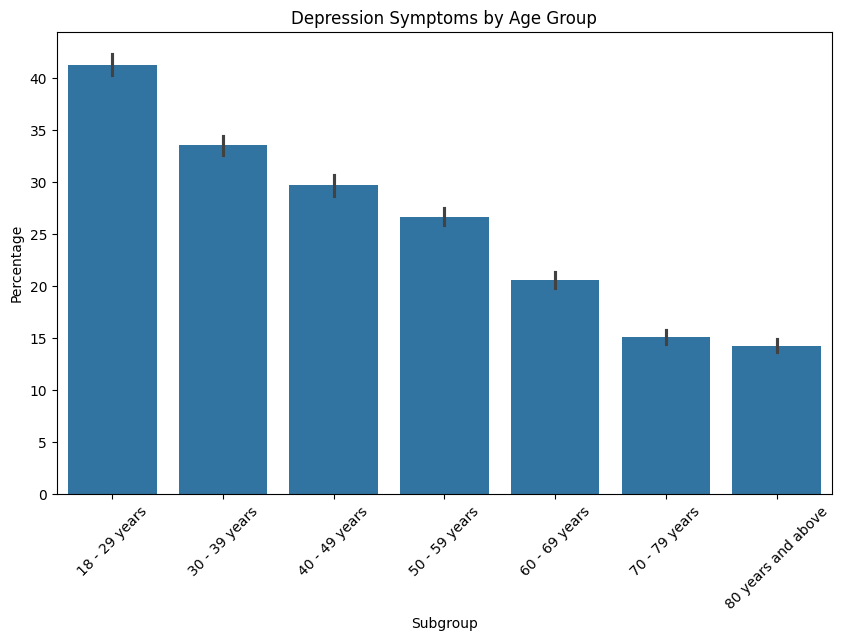

In [38]:
#========================
# SEGMENTATION ANALYSIS
#========================

# 1. Depression Rates by Age Group
age_data = df[df["Group"]=="By Age"]

plt.figure(figsize=(10,6))
sns.barplot(x="Subgroup", y="Value", data=age_data)

plt.xticks(rotation=45)
plt.title("Depression Symptoms by Age Group")
plt.ylabel("Percentage")
plt.show()

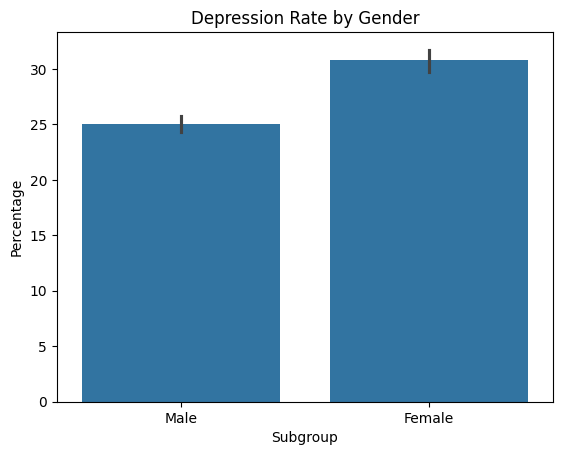

In [39]:
# 2. Depression Rates by Gender
sex_data = df[df["Group"]=="By Sex"]

sns.barplot(x="Subgroup", y="Value", data=sex_data)

plt.title("Depression Rate by Gender")
plt.ylabel("Percentage")
plt.show()

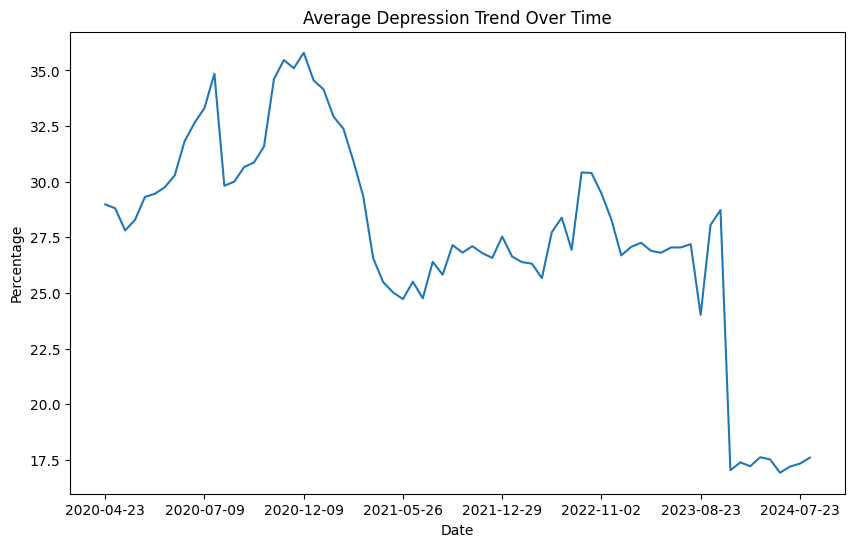

In [40]:
# 3. Mental Health Changes During Pandemic

trend = df.groupby("Time Period Start Date")["Value"].mean()

trend.plot(figsize=(10,6))

plt.title("Average Depression Trend Over Time")
plt.ylabel("Percentage")
plt.xlabel("Date")
plt.show()

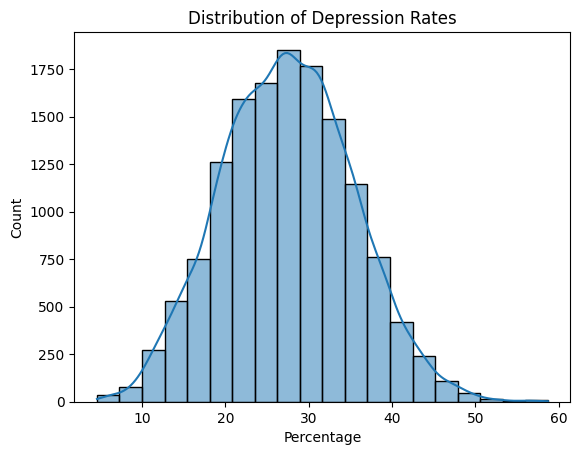

In [41]:
# 4. Distribution of Depression Values

sns.histplot(df["Value"], bins=20, kde=True)

plt.title("Distribution of Depression Rates")
plt.xlabel("Percentage")
plt.show()

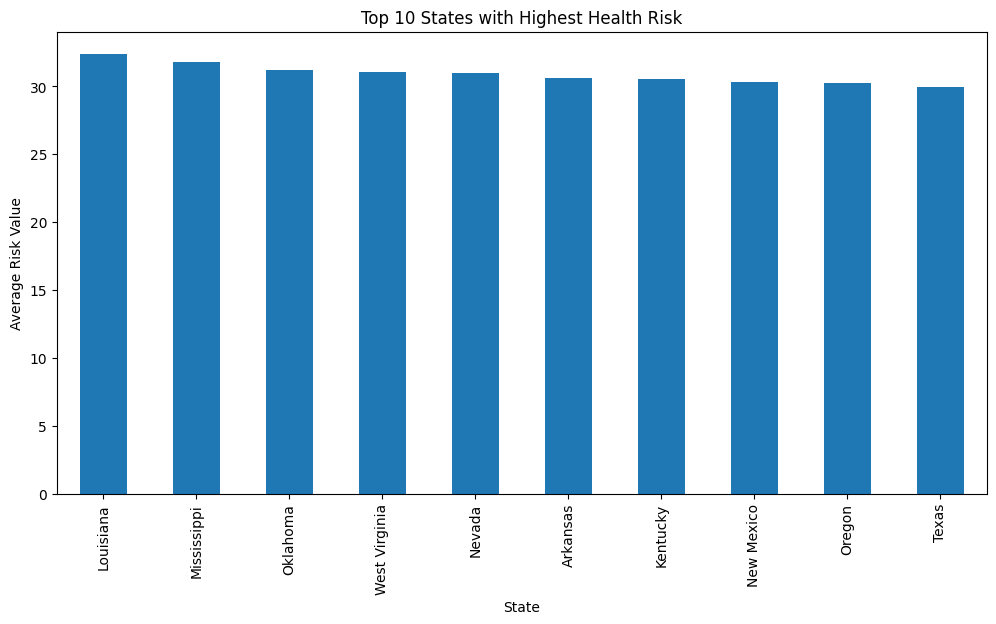

In [43]:
# 5. States with Highest Health Risk
state_risk = df.groupby('State')['Value'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_risk.head(10).plot(kind='bar')
plt.title("Top 10 States with Highest Health Risk")
plt.xlabel("State")
plt.ylabel("Average Risk Value")
plt.show()

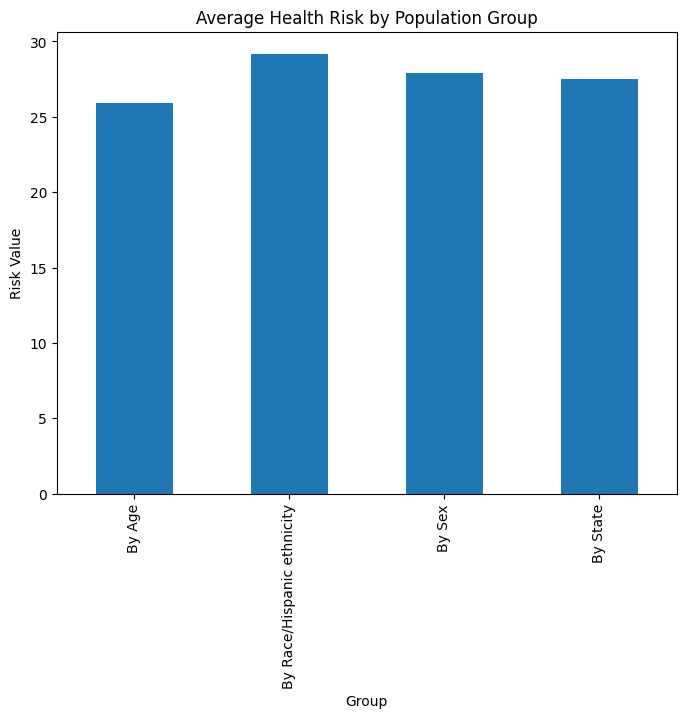

In [44]:
# 6. identify which groups experience higher health risks.
group_risk = df.groupby('Group')['Value'].mean()

group_risk.plot(kind='bar', figsize=(8,6))
plt.title("Average Health Risk by Population Group")
plt.ylabel("Risk Value")
plt.show()

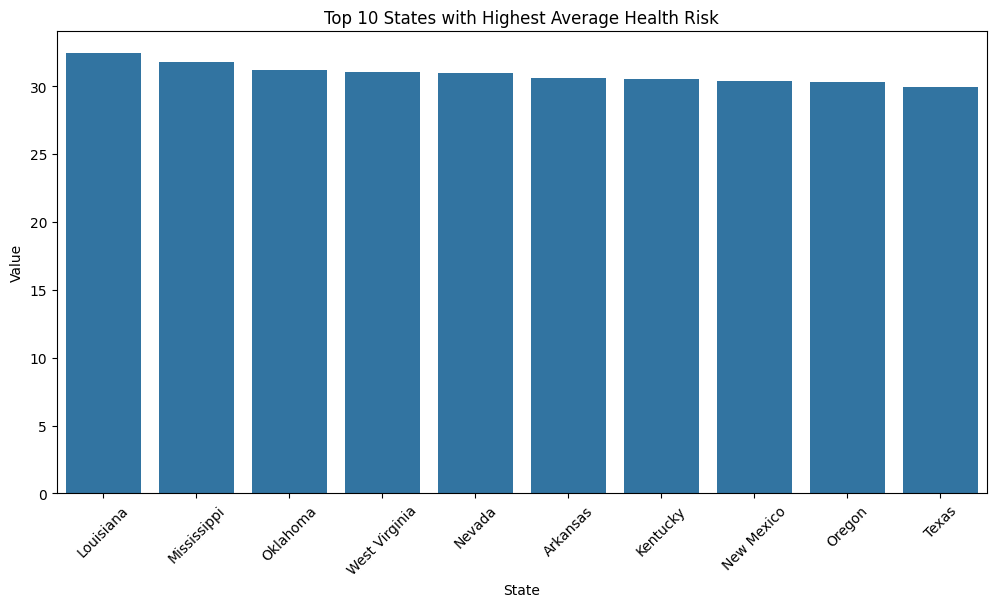

In [47]:
#======================
# AGGREGATION ANALYSIS
#======================

#1. Average health risk value

state_avg = df.groupby('State')['Value'].mean().reset_index()
state_avg = state_avg.sort_values(by='Value', ascending=False)
state_avg.head()
plt.figure(figsize=(12,6))
sns.barplot(x='State', y='Value', data=state_avg.head(10))
plt.title("Top 10 States with Highest Average Health Risk")
plt.xticks(rotation=45)
plt.show()

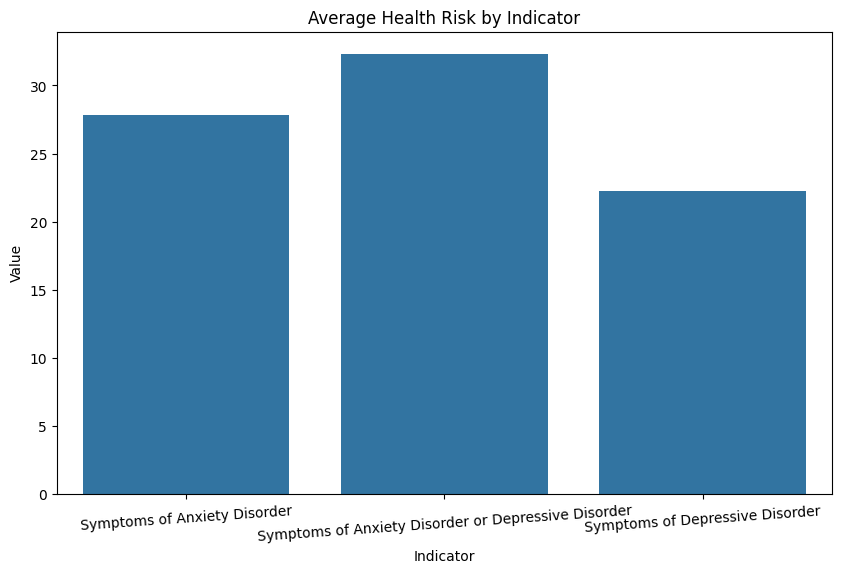

In [58]:
# 2. Average value for each health indicator

indicator_avg = df.groupby('Indicator')['Value'].mean().reset_index()
indicator_avg.sort_values(by='Value', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Indicator', y='Value', data=indicator_avg)
plt.xticks(rotation=4)
plt.title("Average Health Risk by Indicator")
plt.show()

In [63]:
# 3. which states are most affected by specific health conditions.
max_indicator = df.groupby('Indicator')['Value'].max().reset_index()
max_indicator

,Indicator,Value
0,Symptoms of Anxiety Disorder,51.7
1,Symptoms of Anxiety Disorder or Depressive Dis...,58.7
2,Symptoms of Depressive Disorder,43.9


In [64]:
# 4. groups with the lowest risk values

min_indicator = df.groupby('Indicator')['Value'].min().reset_index()
min_indicator

,Indicator,Value
0,Symptoms of Anxiety Disorder,4.6
1,Symptoms of Anxiety Disorder or Depressive Dis...,7.1
2,Symptoms of Depressive Disorder,4.7
